<a href="https://colab.research.google.com/github/codingahahahhaah/compling/blob/main/convnet_hw.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнее задание: бинарная классификация отзывов с помощью CNN

Применить CNN для анализа тональности текста (положительный/отрицательный отзыв)

Заполните пропущенный код (`### ВАШ КОД ЗДЕСЬ ###`). **Не меняйте структуру ячеек!** Все ответы и графики должны генерироваться автоматически

**Критерии проверки (максимум 10 баллов):**
*   **2 балла** — корректная загрузка и предобработка данных.
*   **3 балла** — корректно собранная модель по спецификации.
*   **2 балла** — успешное обучение модели (вывод истории обучения).
*   **3 балла** — оценка на тесте и выводы (accuracy > 0.85 даёт +1 балл).

---

## БЛОК 1: Загрузка данных

Тренировочные данные: 25000 samples
Тестовые данные: 25000 samples


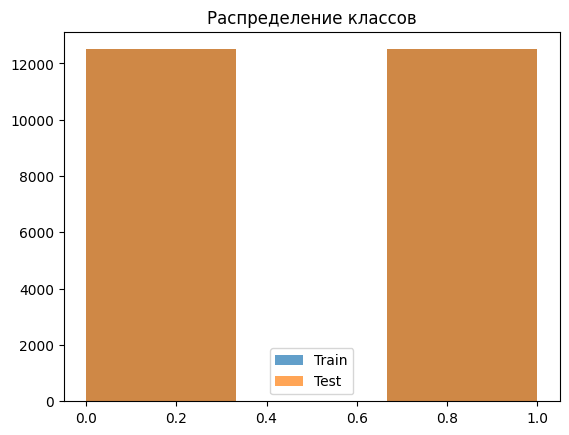

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import tensorflow_datasets as tfds

# 1. Загрузите датасет IMDB Reviews (бинарная классификация)
(x_train, y_train), (x_test, y_test) = tfds.load(
    'imdb_reviews',
    split=['train', 'test'],
    as_supervised=True,
    batch_size=-1
)

x_train = [x.decode('utf-8') for x in x_train.numpy()]
x_test = [x.decode('utf-8') for x in x_test.numpy()]
y_train = y_train.numpy()
y_test = y_test.numpy()

print(f"Тренировочные данные: {len(x_train)} samples")
print(f"Тестовые данные: {len(x_test)} samples")

# 2. Визуализируйте распределение классов
plt.hist(y_train, bins=3, alpha=0.7, label='Train')
plt.hist(y_test, bins=3, alpha=0.7, label='Test')
plt.legend()
plt.title('Распределение классов')
plt.show()

## БЛОК 2: Предобработка текста

In [6]:
# 3. Создайте текстовый векторзатор (TextVectorization)
# Ограничьте словарь 10_000 самых частых слов, максимальную длину последовательности — 200 слов
### ВАШ КОД ЗДЕСЬ ###
vectorizer = keras.layers.TextVectorization(
    max_tokens = 10000,
    output_sequence_length = 200)

# 4. Адаптируйте векторзатор на тренировочных текстах
vectorizer.adapt(x_train)

# 5. Примените векторзацию к данным
x_train_vec = vectorizer(x_train).numpy()
x_test_vec = vectorizer(x_test).numpy()

print(f"Размерность после векторизации: {x_train_vec.shape}")

Размерность после векторизации: (25000, 200)


## БЛОК 3: Построение модели

In [7]:
# 6. Постройте модель CNN для текста СТРОГО ПО СПЕЦИФИКАЦИИ:
#    - Вход: векторная последовательность (200,)
#    - Embedding: размерность 128, входной словарь 10_000
#    - Conv1D: 64 фильтра, размер ядра 5, активация 'relu'
#    - GlobalMaxPooling1D
#    - Dense: 32 нейрона, 'relu'
#    - Dense: 1 нейрон, 'sigmoid' (бинарная классификация)

model = keras.Sequential([
  keras.layers.Embedding(10000, 128, input_length=200),
  keras.layers.Conv1D(64, 5, activation='relu'),
  keras.layers.GlobalMaxPooling1D(),
  keras.layers.Dense(32, activation='relu'),
  keras.layers.Dense(1, activation='sigmoid')
])

model.build(input_shape=(None, 200))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 196, 64)        │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,323,137 (5.05 MB)

 Trainable params: 1,323,137 (5.05 MB)

 Non-trainable params: 0 (0.00 B)

## БЛОК 4: Обучение

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 37s 56ms/step - accuracy: 0.7015 - loss: 0.5497 - precision: 0.6960 - recall: 0.6943 - val_accuracy: 0.8672 - val_loss: 0.3145 - val_precision: 0.8680 - val_recall: 0.8700
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 57ms/step - accuracy: 0.9302 - loss: 0.1911 - precision: 0.9274 - recall: 0.9337 - val_accuracy: 0.8654 - val_loss: 0.3155 - val_precision: 0.8719 - val_recall: 0.8605
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 57ms/step - accuracy: 0.9929 - loss: 0.0402 - precision: 0.9935 - recall: 0.9919 - val_accuracy: 0.8688 - val_loss: 0.3861 - val_precision: 0.8672 - val_recall: 0.8748
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 56ms/step - accuracy: 0.9997 - loss: 0.0058 - precision: 1.0000 - recall: 0.9993 - val_accuracy: 0.8702 - val_loss: 0.4413 - val_precision: 0.8737 - val_recall: 0.8692
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 56ms/step - accuracy: 1.0000 - loss: 0.0012 - precision: 0.9999 - recall: 1.0000 - val_accuracy: 0.8684 - val_los

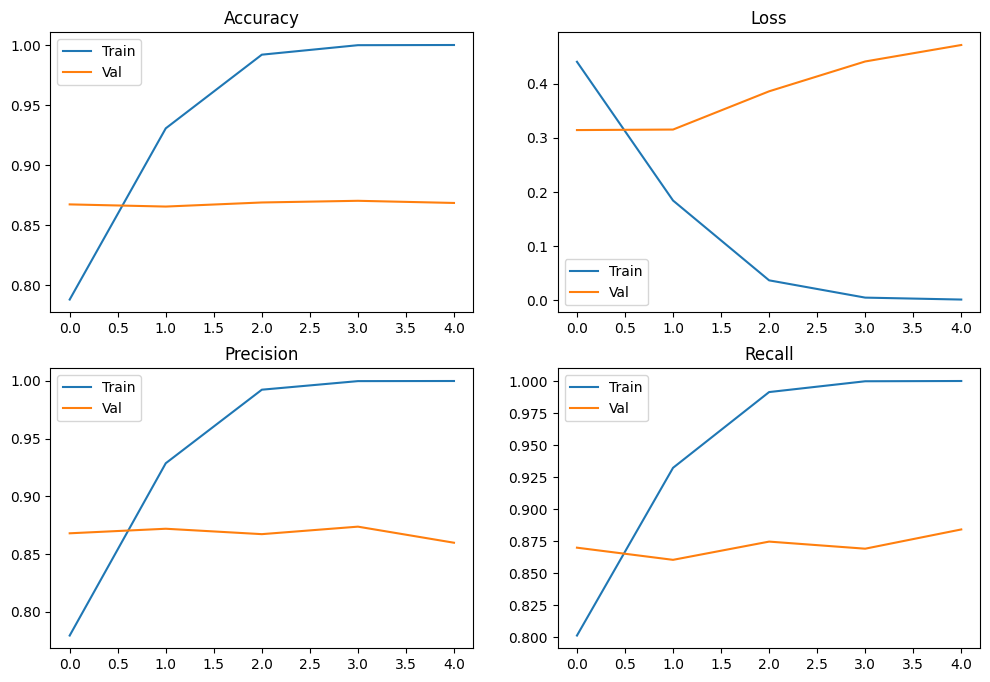

In [12]:
# 7. Скомпилируйте модель с оптимизатором 'adam', функцией потерь 'binary_crossentropy',
#    метриками ['accuracy', 'Precision', 'Recall']
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', 'precision', 'recall'])


# 8. Обучите модель на 5 эпох с validation_split=0.2, batch_size=32

history = model.fit(x_train_vec, y_train,
                    epochs=5,
                    validation_split=0.2,
                    batch_size=32,
                    verbose=1)

# 9. Постройте график точности (accuracy) на обучении и валидации
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].plot(history.history['accuracy'], label='Train')
axes[0,0].plot(history.history['val_accuracy'], label='Val')
axes[0,0].set_title('Accuracy')
axes[0,0].legend()

axes[0,1].plot(history.history['loss'], label='Train')
axes[0,1].plot(history.history['val_loss'], label='Val')
axes[0,1].set_title('Loss')
axes[0,1].legend()

axes[1,0].plot(history.history['precision'], label='Train')
axes[1,0].plot(history.history['val_precision'], label='Val')
axes[1,0].set_title('Precision')
axes[1,0].legend()

axes[1,1].plot(history.history['recall'], label='Train')
axes[1,1].plot(history.history['val_recall'], label='Val')
axes[1,1].set_title('Recall')
axes[1,1].legend()
plt.show()

## БЛОК 5: Оценка

In [14]:
test_loss, test_acc, test_prec, test_rec = model.evaluate(x_test_vec, y_test, verbose=0)
print(f"Тестовая accuracy: {test_acc:.4f}")
print(f"Тестовая precision: {test_prec:.4f}")
print(f"Тестовая recall: {test_rec:.4f}")

# 11. Сделайте предсказания на первых 10 тестовых отзывах
for i in range(10):
    text = x_test[i]
    true_label = "POS" if y_test[i] == 1 else "NEG"

    sample_input = np.expand_dims(x_test_vec[i], axis=0)  # (1, 200)
    pred_prob = model.predict(sample_input, verbose=0)
    pred_label = "POS" if pred_prob[0][0] > 0.5 else "NEG"

    print(f"{text[:50]}... | True: {true_label} | Pred: {pred_label} ({pred_prob[0][0]:.2f})")

Тестовая accuracy: 0.8681
Тестовая precision: 0.8680
Тестовая recall: 0.8682
There are films that make careers. For George Rome... | True: POS | Pred: POS (1.00)
A blackly comic tale of a down-trodden priest, Naz... | True: POS | Pred: POS (0.99)
Scary Movie 1-4, Epic Movie, Date Movie, Meet the ... | True: NEG | Pred: NEG (0.00)
Poor Shirley MacLaine tries hard to lend some grav... | True: NEG | Pred: NEG (0.02)
As a former Erasmus student I enjoyed this film ve... | True: POS | Pred: POS (1.00)
My God, Ryan Gosling has made a lot of deep charac... | True: POS | Pred: POS (1.00)
This film just won the best film award at the Clev... | True: POS | Pred: POS (1.00)
The cast for this production of Rigoletto is excel... | True: POS | Pred: POS (1.00)
As long as you keep in mind that the production of... | True: NEG | Pred: NEG (0.49)
Every great once in a while, you stumble upon a mo... | True: POS | Pred: NEG (0.03)


## БЛОК 6: Выводы

**Ответьте на вопросы в этой ячейке (текстом):**

1.  Какая итоговая точность (accuracy) на тесте?
2.  Что показывает разница между точностью на обучении и валидации? Есть ли переобучение?
3.  Какой из 10 показанных отзывов был классифицирован неверно? Почему, на ваш взгляд?

**Мои ответы:**
1.  Итоговая точность = 0.8681, то есть примерно 87% с округлением
2.  Разница между точностью на обучении и валидации присутствует и бросается в глаза. Точность на обучении варьируется от 0.70 до 1.00. Разброс не критичный, но заметный, что указывает на небольшое переобучение модели. Вероятно связано это с тем, что мне приходилось несколько раз прогогнять чанки с кодом, в том числе чанк с обучением модели. Предполагаю, что если бы я сразу написала верный код, то переобучения бы не было.
3.  Последний отзыв был классифицирован неверно. Он был оценен как позитивный, однако модель предсказала негативную окраску текста. Это может произойти по ряду причин: скрытая ирония в тексте, смешанная эмоциональная окраска или просто слов из этого отзыва не было в обучающем материале, и модели пришлось "угадывать".
